## Child Development Risk Analysis Using NSCH Data
##### Analyzing behavioral, family, and environmental factors associated with child health risk in the United States using the National Survey of Children’s Health (NSCH).

### Project Overview

- This project explores factors associated with child health and developmental risk using the National Survey of Children’s Health (NSCH). The analysis focuses on two age groups separately: young children aged 0–5 and older children aged 6–17.

- The project combines SQL and Python in a practical analytics workflow:

    - BigQuery SQL was used for data cleaning, feature selection, and cohort construction
    - Python is used for exploratory data analysis, visualization, and predictive modeling

- The broader motivation for this project is a product idea: a parent-focused application that helps families better understand child development risk factors and monitor important behavioral and environmental signals.

### Business / Product Context

- Parents often receive fragmented information about child health, development, daily routines, and family well-being. Important factors such as sleep, screen time, physical activity, food security, and stressful life experiences may all influence child outcomes, but they are rarely evaluated together in a simple and practical way.

- This project is motivated by the idea of creating a digital tool for parents that could:
    - identify important risk signals
    - highlight cumulative risk
    - provide understandable insights about child well-being

- From an analytics perspective, this project demonstrates how survey data can be transformed into interpretable risk segments and actionable insights.

### Problem Statement

- Which behavioral, environmental, and socioeconomic factors are associated with a higher likelihood of special health care needs in children?

- To answer this question, I use the NSCH dataset to examine selected factors related to:

    - lifestyle and daily routines
    - family context
    - neighborhood and food security
    - adverse childhood experiences

- The main outcome variable in the analysis is CSHCN_2324, which indicates whether a child has special health care needs.

### Analytical Goals

##### The main goals of this project are:

1. Understand key drivers of child health risk
    - Identify how behavioral, environmental, and socioeconomic factors are associated with the likelihood of special health care needs (CSHCN_2324).
2. Build clean, age-specific datasets
    - Prepare separate analytical datasets for children aged 0–5 and 6–17 to account for age-specific survey variables and ensure meaningful comparisons.
3. Perform cohort-based analysis using SQL
    - Use BigQuery to create multi-factor cohorts and analyze how combinations of risk factors influence child health outcomes.
4. Analyze cumulative risk effects
    - Evaluate how the number of risk factors (e.g., high screen time, low physical activity, food insecurity) relates to increasing probability of health issues.
5. Conduct exploratory data analysis (EDA)
    - Explore distributions and relationships between selected features and the target variable to validate assumptions and identify patterns.
6. Develop an interpretable predictive model
    - Build a baseline machine learning model (logistic regression) to assess how well selected factors can predict child health risk.
7. Translate analysis into actionable insights
    - Provide clear, interpretable findings that could support a parent-focused application for monitoring child development and risk factors.

### Dataset Description

- The analysis is based on the 2023–2024 National Survey of Children’s Health (NSCH), a nationally representative U.S. survey on child health and well-being. The dataset includes information on child and family demographics, health and developmental status, daily routines, household conditions, and neighborhood context.

- The NSCH is a child-level survey in which one child is randomly selected from each eligible household for the topical questionnaire. Results are weighted to represent the population of children rather than parents.

- Because the survey includes age-specific questions, the analysis is conducted separately for:
    - children aged 0–5
    - children aged 6–17

- This separation improves interpretability and avoids structural missingness caused by age-restricted variables.

### Survey Weight

Because NSCH is a survey dataset, each row does not represent the same number of children in the U.S. population. I use `fwc_2324`, the final child-level survey weight, to calculate weighted CSHCN rates and weighted distributions.

This means that charts such as the target distribution, socioeconomic comparisons, and risk accumulation rates are interpreted as population-level estimates rather than only raw sample patterns.

### Data Preparation

- Data preparation was performed in BigQuery using SQL. The main steps included:

    - selecting relevant columns for each age group
    - filtering the dataset into two separate age-specific tables
    - converting survey-specific missing codes (90, 95, 99) to NULL
    - checking for duplicate rows
    - creating cleaned analytical tables for downstream analysis

- This workflow created a reproducible SQL-based pipeline and separated data preparation from exploratory analysis and modeling.

### Why the Dataset Was Split by Age Group

- The NSCH contains many age-specific variables. Some variables are only asked for younger children, while others are only relevant for older children. For example, reading-related variables are relevant for early childhood, while physical activity variables are more appropriate for older children. The survey also uses different topical questionnaires by age group.

- Using a single combined table for all children would introduce structural missingness and reduce interpretability. By splitting the analysis into 0–5 and 6–17 groups, I was able to:
    - use features only where they are relevant
    - avoid misleading comparisons
    - produce more meaningful age-specific insights

### Feature Selection Strategy

- I selected features that represent potential drivers of child health risk rather than variables that directly describe the outcome itself.

- The selected features fall into four groups:
    - behavioral factors such as screen time, sleep, and physical activity
    - family-related factors such as shared meals and reading
    - socioeconomic factors such as poverty level and adult education
    - environmental and stress-related factors such as food security, neighborhood safety, and adverse childhood experiences

- Outcome-like variables that are conceptually too close to the target were excluded from the main predictive logic to avoid leakage and preserve interpretability.

### Selected Features
##### Children aged 0–5
- age3_2324
- sex_2324
- ScreenTime_2324
- HrsSleep_2324
- readto_2324
- MealTogether_2324
- povlev4_2324
- AdultEduc_2324
- NbhdSafe_2324
- FoodSit_2324
- ACE2more_2324
- flrish0to5_2324
- fwc_2324
##### Children aged 6–17
- age3_2324
- sex_2324
- ScreenTime_2324
- HrsSleep_2324
- PhysAct_2324
- MealTogether_2324
- povlev4_2324
- AdultEduc_2324
- NbhdSafe_2324
- FoodSit_2324
- ACE2more_2324
- flrish6to17_2324
- fwc_2324
##### Target variable
- CSHCN_2324

### Feature Description
##### Target Variable
- CSHCN_2324 — Children with Special Health Care Needs. Indicates whether a child has chronic physical, developmental, behavioral, or emotional conditions requiring additional support.

    - 1 — Yes
    - 2 — No

##### Demographic Features
- age3_2324 — Age Group

    - 1 — 0–5 years
    - 2 — 6–11 years
    - 3 — 12–17 years

- sex_2324 — Child’s Sex

    - 1 — Male
    - 2 — Female

##### Lifestyle Features

- ScreenTime_2324 — Daily Screen Time
Higher values indicate greater screen exposure.

- HrsSleep_2324 — Adequate Sleep
Used to indicate whether a child gets enough sleep.

- PhysAct_2324 — Physical Activity (6–17 only)
Represents the number of days per week a child is physically active.

##### Family & Parenting Features

- readto_2324 — Frequency of Reading to Child (0–5 only)
Reflects how often a child is read to.

- MealTogether_2324 — Family Meals per Week
Represents how often the family eats together.

##### Socioeconomic Features

- povlev4_2324 — Poverty Level
Represents grouped poverty or income status.

- AdultEduc_2324 — Highest Education Level in Household
Represents the highest household adult education category.

##### Environmental and Stress Features

- NbhdSafe_2324 — Neighborhood Safety
Captures the caregiver’s perception of neighborhood safety.

- FoodSit_2324 — Food Security
Indicates whether the household has enough food.

- ACE2more_2324 — Adverse Childhood Experiences
Indicates the presence of adverse experiences, with higher values reflecting greater exposure to stressors.

##### Development Indicator

- flrish0to5_2324 / flrish6to17_2324 — Flourishing
Represents positive emotional and developmental well-being.

##### Survey weight
- fwc_2324 — Final child-level survey weight used to calculate population-representative estimates.

### Analysis Roadmap

##### The project is organized into three main analytical stages:

1. SQL-based data preparation and cohort construction
    - Build clean, age-specific analytical tables and create multi-factor risk cohorts.
2. Exploratory data analysis (EDA)
    - Explore the distribution of the target variable and relationships between selected features and child health risk.
3. Predictive modeling
    - Train an interpretable machine learning model to evaluate how selected factors relate to the likelihood of special health care needs.

### Focus of the Current Analysis: Children Aged 6–17

- I begin with children aged 6–17 because this group includes a strong set of behavioral and environmental variables such as physical activity, sleep, screen time, food security, neighborhood safety, and adverse childhood experiences.

- The first analytical step for this group is a multi-factor risk cohort analysis, which identifies combinations of risk factors associated with higher rates of special health care needs.

### Multi-factor Risk Cohort Analysis

- For children aged 6–17, I created cohorts based on combinations of key behavioral and environmental factors:
    - screen time
    - sleep adequacy
    - physical activity
    - food security
    - neighborhood safety
    - adverse childhood experiences

- The goal of this analysis is to identify profiles of children who are more likely to have special health care needs. This approach provides a more realistic view of child risk than analyzing one variable at a time.

### Cumulative Risk Analysis

- In addition to the detailed cohort analysis, I created a simplified cumulative risk measure by counting the number of risk factors present for each child.

- This allows me to test whether the likelihood of special health care needs increases as the number of unfavorable conditions increases. The cumulative risk approach is easier to visualize and supports a clear, interpretable story.

In [606]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.stats.proportion import proportions_ztest



In [607]:
df = pd.read_csv("6-17_children.csv", index_col=0)

df_multi_factors = pd.read_csv("multi_factor_risk.csv", index_col=False)

df_risk_factor_counts = pd.read_csv("risk_factor_counts.csv", index_col=False)

df_top = pd.read_csv("top_combinations.csv", index_col=False)


In [608]:
df_clean = df.dropna().copy()

In [609]:
print(f"{(1 - df_clean.shape[0]/df.shape[0]) * 100:.2f}% lost due to missing values.")


4.44% lost due to missing values.


In [610]:
df_clean = df_clean.rename(columns={
    'sex_2324': 'sex',
    'ScreenTime_2324': 'screen_time',
    'HrsSleep_2324': 'sleep',
    'PhysAct_2324': 'physical_activity',
    'MealTogether_2324': 'meals_together',
    'NbhdSafe_2324': 'neighborhood_safety',
    'FoodSit_2324': 'food_security',
    'ACE2more_2324': 'ace',
    'povlev4_2324': 'poverty_level',
    'AdultEduc_2324': 'parent_education',
    'flrish6to17_2324': 'flourishing',
    'CSHCN_2324': 'target',
    'fwc_2324': 'weight'
})

In [611]:
df_clean['sleep_group'] = df_clean['sleep'].map({
    1: 'Enough sleep',
    2: 'Not enough sleep'
})

df_clean['ace_group'] = df_clean['ace'].map({
    1: 'No ACE',
    2: 'One ACE',
    3: 'Two or more ACEs'
})

df_clean['screen_group'] = df_clean['screen_time'].map({
    1: 'Low',
    2: 'Moderate',
    3: 'High',
    4: 'Very high',
    5: 'Extreme'
})

df_clean['education_group'] = df_clean['parent_education'].map({
    1: 'Low education',
    2: 'School',
    3: 'College',
    4: 'High degree'
})

df_clean['poverty_group'] = df_clean['poverty_level'].map({
    1: 'High poverty',
    2: 'Moderate poverty',
    3: 'Middle income',
    4: 'High income'
})

df_clean['food_insecure'] = df_clean['food_security'].isin([3,4]).astype(int)

### Missing Data Handling

##### The dataset contained a relatively small proportion of missing values (approximately 4.5%). Given the low level of missingness, rows with missing values were removed using a complete-case approach. This ensured a clean dataset without introducing potential bias from imputation methods, while preserving the majority of observations.

## Exploratory Data Analysis

### How many observations?

In [612]:
print(df_clean.shape[0], "observations")
print(df_clean["weight"].sum(), "weighted population estimate")

68013 observations
47456550.75374775 weighted population estimate


After cleaning, the final dataset contains **68,013 observations**. 
After applying the survey weight, these observations represent approximately 
**47.5 million U.S. children aged 6–17**.

This difference is expected because NSCH is a weighted survey: each sampled child can represent many children in the broader U.S. population.

### Target Distribution

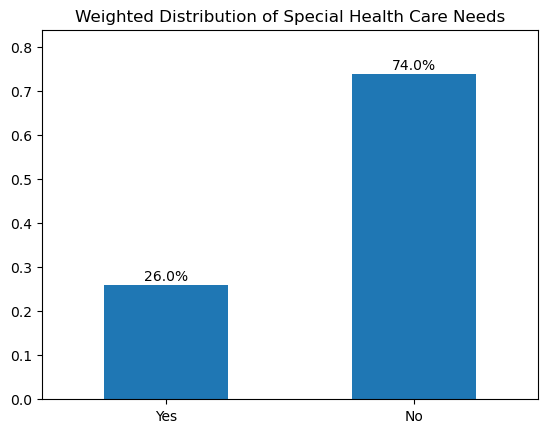

In [613]:
# Get proportions
counts = df_clean.groupby('target')['weight'].sum()
counts /= counts.sum()

counts.index = counts.index.map({1: 'Yes', 2: 'No'})

ax = counts.plot(kind='bar')

plt.title('Weighted Distribution of Special Health Care Needs')
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha='center')

plt.ylim(0, counts.max() + 0.1)
plt.xlabel('')

plt.show()

Approximately 26% of children in the dataset have special health care needs, while 74% do not. This indicates a moderately imbalanced dataset, which should be considered when building predictive models.

#### Before analyzing risk factors, we need to understand who is represented in the data. Let's look at distribution of parental education and poverty level.

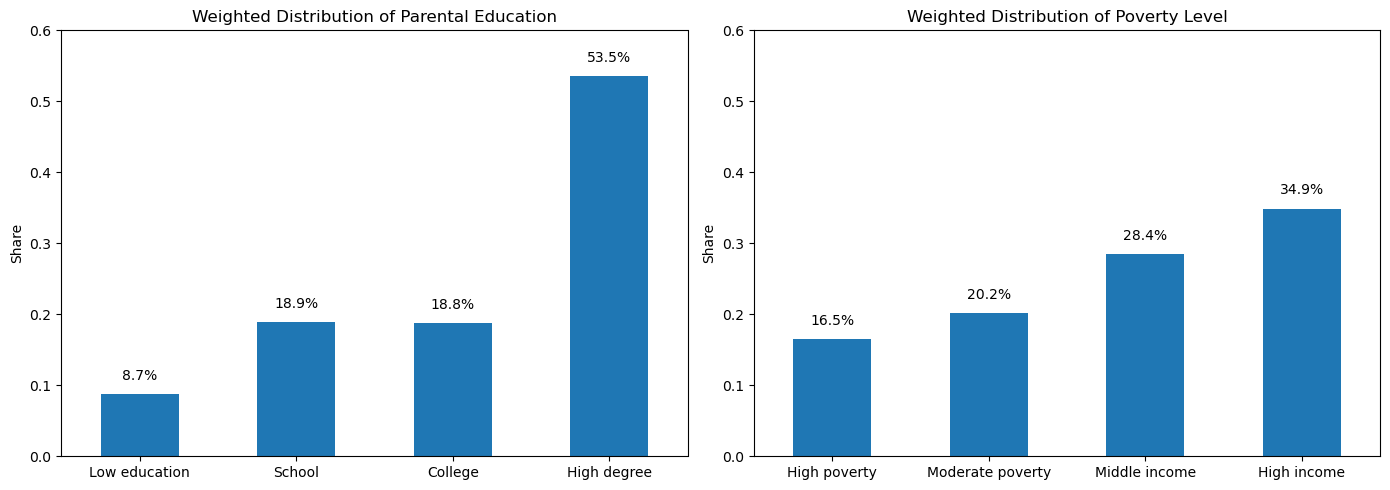

In [614]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Education (weighted) ---
edu_dist = (
    df_clean
    .dropna(subset=['education_group', 'weight'])
    .groupby('education_group')['weight']
    .sum()
    .reindex(['Low education', 'School', 'College', 'High degree'])
)

edu_dist = edu_dist / edu_dist.sum()  # normalize

edu_dist.plot(kind='bar', ax=axes[0])

axes[0].set_title('Weighted Distribution of Parental Education')
axes[0].set_xlabel('')
axes[0].set_ylabel('Share')
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(edu_dist):
    axes[0].text(i, v + 0.02, f'{v*100:.1f}%', ha='center')


# --- Poverty (weighted) ---
pov_dist = (
    df_clean
    .dropna(subset=['poverty_group', 'weight'])
    .groupby('poverty_group')['weight']
    .sum()
    .reindex(['High poverty', 'Moderate poverty', 'Middle income', 'High income'])
)

pov_dist = pov_dist / pov_dist.sum()  # normalize

pov_dist.plot(kind='bar', ax=axes[1])

axes[1].set_title('Weighted Distribution of Poverty Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('Share')
axes[1].set_ylim(0, 0.6)
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(pov_dist):
    axes[1].text(i, v + 0.02, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

The dataset is highly skewed toward middle - higher income and highly educated families, with disadvantaged groups underrepresented. This distribution should be considered when interpreting patterns in the data.

### How CSHCN Is Distributed Across Education and Poverty Levels

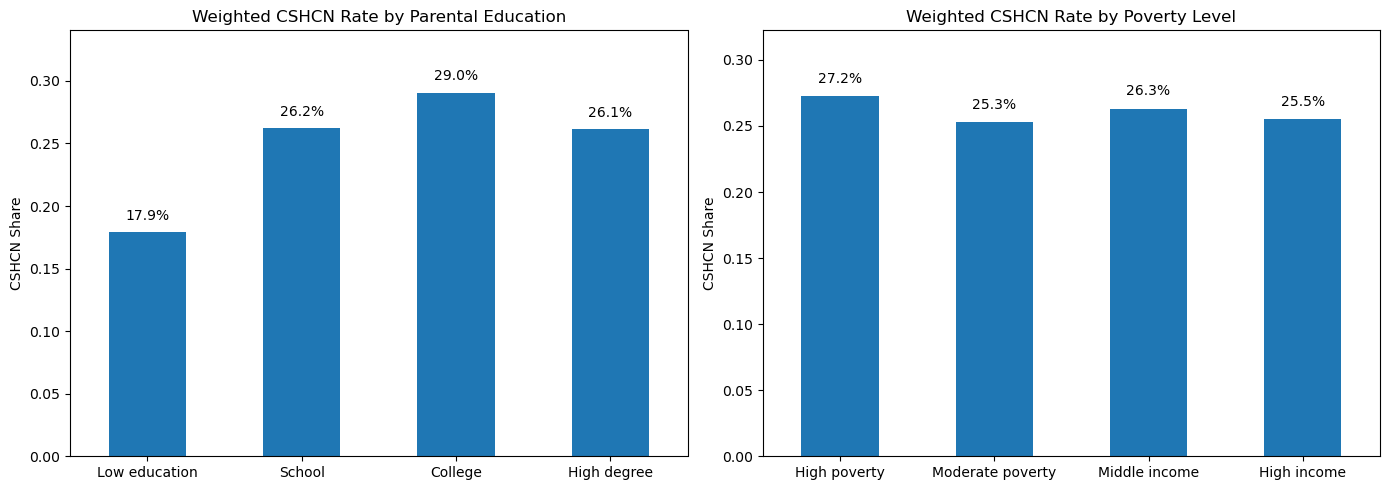

In [615]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# make binary target: 1 = CSHCN, 0 = Non-CSHCN
df_clean['cshcn_binary'] = df_clean['target'].map({1: 1, 2: 0})

# --- Weighted CSHCN rate by education ---
edu_cshcn = (
    df_clean
    .dropna(subset=['education_group', 'cshcn_binary', 'weight'])
    .assign(weighted_cshcn=lambda x: x['cshcn_binary'] * x['weight'])
    .groupby('education_group')[['weighted_cshcn', 'weight']]
    .sum()
    .assign(rate=lambda x: x['weighted_cshcn'] / x['weight'])
    ['rate']
    .reindex(['Low education', 'School', 'College', 'High degree'])
)

edu_cshcn.plot(kind='bar', ax=axes[0])

axes[0].set_title('Weighted CSHCN Rate by Parental Education')
axes[0].set_xlabel('')
axes[0].set_ylabel('CSHCN Share')
axes[0].set_ylim(0, max(edu_cshcn) + 0.05)
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(edu_cshcn):
    axes[0].text(i, v + 0.01, f'{v*100:.1f}%', ha='center')


# --- Weighted CSHCN rate by poverty ---
pov_cshcn = (
    df_clean
    .dropna(subset=['poverty_group', 'cshcn_binary', 'weight'])
    .assign(weighted_cshcn=lambda x: x['cshcn_binary'] * x['weight'])
    .groupby('poverty_group')[['weighted_cshcn', 'weight']]
    .sum()
    .assign(rate=lambda x: x['weighted_cshcn'] / x['weight'])
    ['rate']
    .reindex(['High poverty', 'Moderate poverty', 'Middle income', 'High income'])
)

pov_cshcn.plot(kind='bar', ax=axes[1])

axes[1].set_title('Weighted CSHCN Rate by Poverty Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('CSHCN Share')
axes[1].set_ylim(0, max(pov_cshcn) + 0.05)
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(pov_cshcn):
    axes[1].text(i, v + 0.01, f'{v*100:.1f}%', ha='center')

plt.tight_layout()
plt.show()

CSHCN rates are relatively consistent across income groups, but increase with parental education. This suggests that differences may reflect awareness and reporting rather than true variation in child health, highlighting the importance of guidance tools for parents with lower access to information.

## Distribution of Risk Factor Counts

### How Does Risk Accumulation Affect CSHCN Rates Across Age Groups?

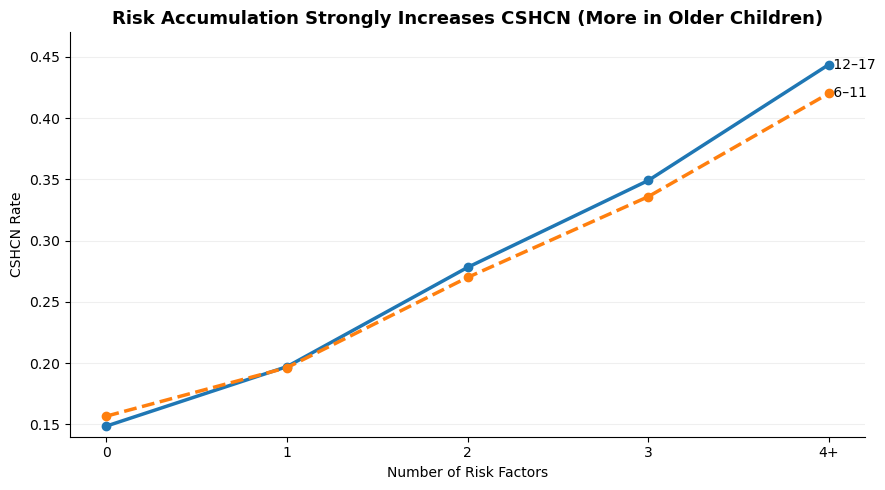

In [616]:
df_plot = df_risk_factor_counts.copy()

# make sure order is correct
order = ['0', '1', '2', '3', '4+']
df_plot['risk_factor_group'] = pd.Categorical(
    df_plot['risk_factor_group'], categories=order, ordered=True
)

df_plot = df_plot.sort_values(['age3_2324', 'risk_factor_group'])

age_6_11 = df_plot[df_plot['age3_2324'] == '6-11']['cshcn_rate']
age_12_17 = df_plot[df_plot['age3_2324'] == '12-17']['cshcn_rate']
x = order

plt.figure(figsize=(9, 5))

plt.plot(x, age_12_17, marker='o', linewidth=2.5)
plt.plot(x, age_6_11, marker='o', linewidth=2.5, linestyle='--')

# labels at end
plt.text(len(x)-1, age_12_17.iloc[-1], ' 12–17', va='center')
plt.text(len(x)-1, age_6_11.iloc[-1], ' 6–11', va='center')

plt.title('Risk Accumulation Strongly Increases CSHCN (More in Older Children)',
          fontsize=13, fontweight='bold')

plt.xlabel('Number of Risk Factors')
plt.ylabel('CSHCN Rate')

plt.ylim(0.14, 0.47)
plt.grid(axis='y', alpha=0.2)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

1. The relationship between accumulated risk factors and CSHCN is consistent across age groups, indicating that risk accumulation affects children similarly at different developmental stages.

2. Older children show slightly higher CSHCN rates at the same risk level, possibly reflecting longer exposure to risk factors.

### Statistical Test: Do CSHCN Rates Differ Significantly by Number of Risk Factors?

In [617]:
df_risk = df_risk_factor_counts.copy()

for age_group in ['6-11', '12-17']:
    print(f"\n=== Age group: {age_group} ===")
    
    df_age = df_risk[df_risk['age3_2324'] == age_group]

    comparisons = [('0', '1'), ('1', '2'), ('2', '3'), ('3', '4+')]

    for a, b in comparisons:
        g1 = df_age[df_age['risk_factor_group'] == a]
        g2 = df_age[df_age['risk_factor_group'] == b]

        success_1 = (g1['cshcn_rate'] * g1['total_children']).sum()
        success_2 = (g2['cshcn_rate'] * g2['total_children']).sum()

        n_1 = g1['total_children'].sum()
        n_2 = g2['total_children'].sum()

        z_stat, p_value = proportions_ztest(
            count=[success_1, success_2],
            nobs=[n_1, n_2]
        )

        rate_1 = success_1 / n_1
        rate_2 = success_2 / n_2

        print(f"\n{a} vs {b}")
        print(f"{a}: {rate_1:.2%}, {b}: {rate_2:.2%}")
        print(f"Diff: {(rate_2 - rate_1):.2%}")
        print(f"P-value: {p_value:.4}")


=== Age group: 6-11 ===

0 vs 1
0: 15.68%, 1: 19.64%
Diff: 3.96%
P-value: 0.0

1 vs 2
1: 19.64%, 2: 27.00%
Diff: 7.36%
P-value: 0.0

2 vs 3
2: 27.00%, 3: 33.59%
Diff: 6.59%
P-value: 0.0

3 vs 4+
3: 33.59%, 4+: 42.02%
Diff: 8.43%
P-value: 0.0

=== Age group: 12-17 ===

0 vs 1
0: 14.87%, 1: 19.72%
Diff: 4.85%
P-value: 0.0

1 vs 2
1: 19.72%, 2: 27.82%
Diff: 8.10%
P-value: 0.0

2 vs 3
2: 27.82%, 3: 34.91%
Diff: 7.09%
P-value: 0.0

3 vs 4+
3: 34.91%, 4+: 44.37%
Diff: 9.46%
P-value: 0.0


#### CSHCN rates rise significantly with each additional risk factor, with stronger effects observed among older children.

### What Are the Top Risk Factor Combinations for Each Parental Education Group?

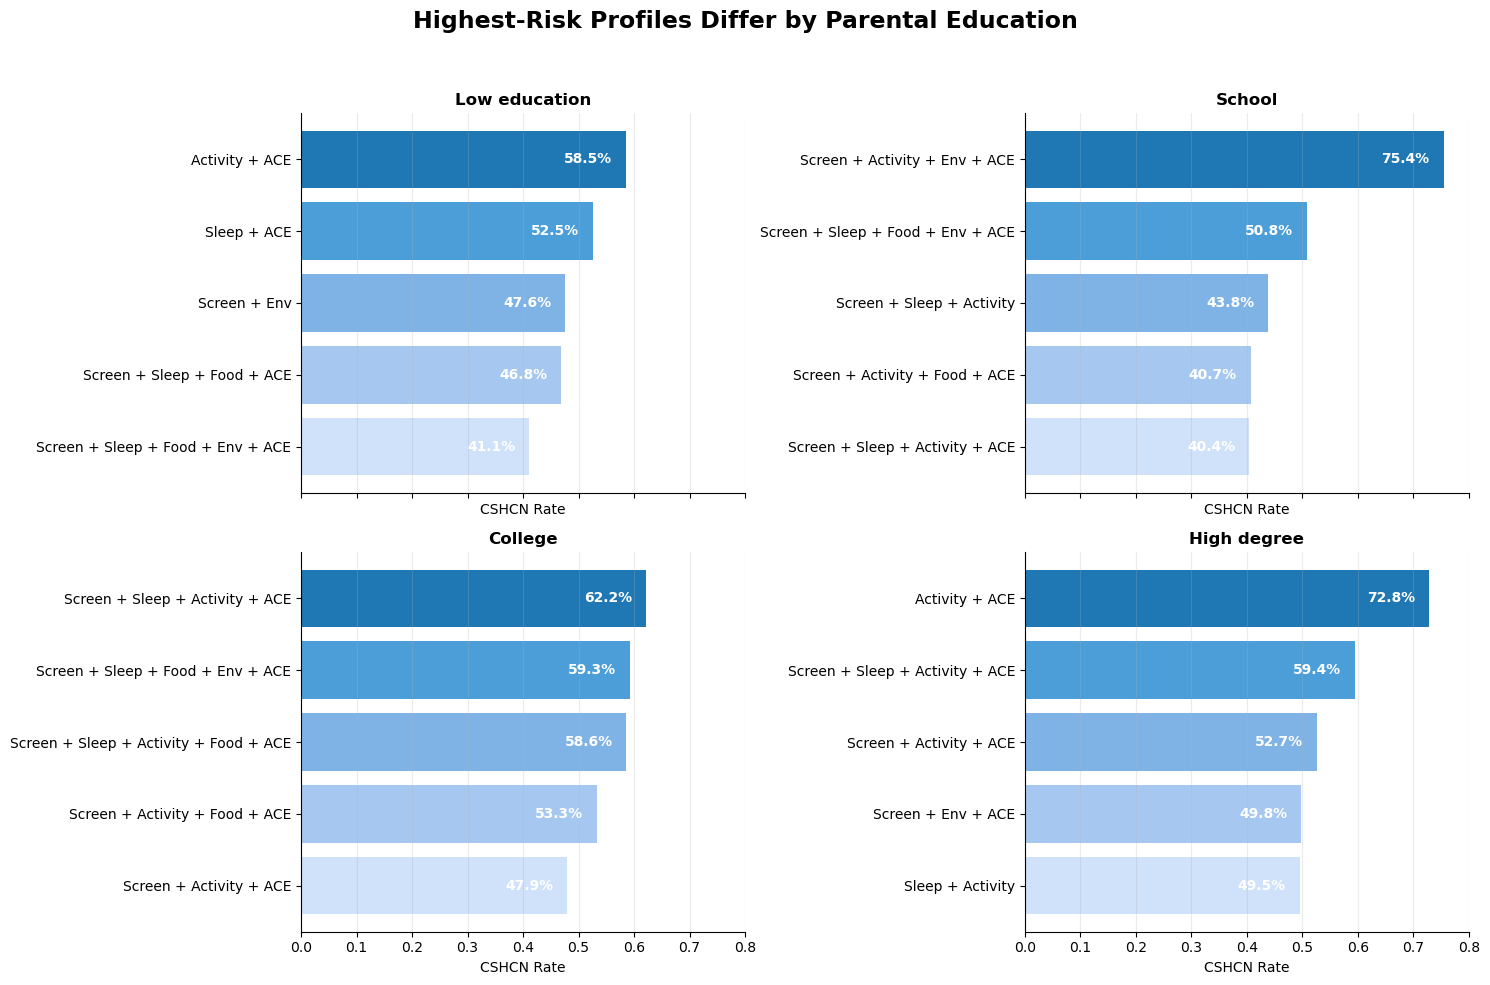

In [618]:
df_top["combo_clean"] = (
    df_top["combo"]
    .str.rstrip("+")
    .str.replace("+", " + ", regex=False)
    .str.replace("Neighborhood", "Env", regex=False)
)

education_levels = ["Low education", "School", "College", "High degree"]

colors = ["#1f77b4", "#4c9ed9", "#7fb3e6", "#a6c8f0", "#d0e1fa"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for i, edu in enumerate(education_levels):
    temp = (
        df_top[df_top["AdultEduc_2324"] == edu]
        .sort_values("cshcn_rate", ascending=False)
        .head(5)
        .copy()
    )

    axes[i].barh(
        temp["combo_clean"],
        temp["cshcn_rate"],
        color=colors[:len(temp)]
    )

    axes[i].invert_yaxis()
    axes[i].set_title(edu, fontsize=12, fontweight="bold")
    axes[i].set_xlim(0, 0.8)
    axes[i].set_xlabel("CSHCN Rate")
    axes[i].grid(axis="x", alpha=0.25)

    # remove top/right borders
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    # percentage labels inside bars
    for j, v in enumerate(temp["cshcn_rate"]):
        axes[i].text(
            v - 0.025,
            j,
            f"{v*100:.1f}%",
            va="center",
            ha="right",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

fig.suptitle(
    "Highest-Risk Profiles Differ by Parental Education",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Across all parental education groups, combinations that include ACEs show the highest CSHCN rates. However, the other risk factors paired with ACEs vary by education level, suggesting that support strategies should be tailored rather than one-size-fits-all.

### Which Risk Profiles Have the Highest and Lowest CSHCN Rates?

In [619]:
top = df_multi_factors[df_multi_factors['total_children'] >= 50000].sort_values('cshcn_rate', ascending=False).head(20)
low = df_multi_factors[df_multi_factors['total_children'] >= 50000].sort_values('cshcn_rate', ascending=True).head(20)

label_map = {
    'Not enough sleep': 'Low sleep',
    'Enough sleep': 'Good sleep',
    'High screen': 'High',
    'Moderate screen': 'Moderate',
    'Low screen': 'Low',
    'Low activity': 'Low',
    'Medium activity': 'Med',
    'High activity': 'High',
    'Two or more ACEs': '2+ ACE',
    'One ACE': '1 ACE',
    'No ACE': '0 ACE'
}


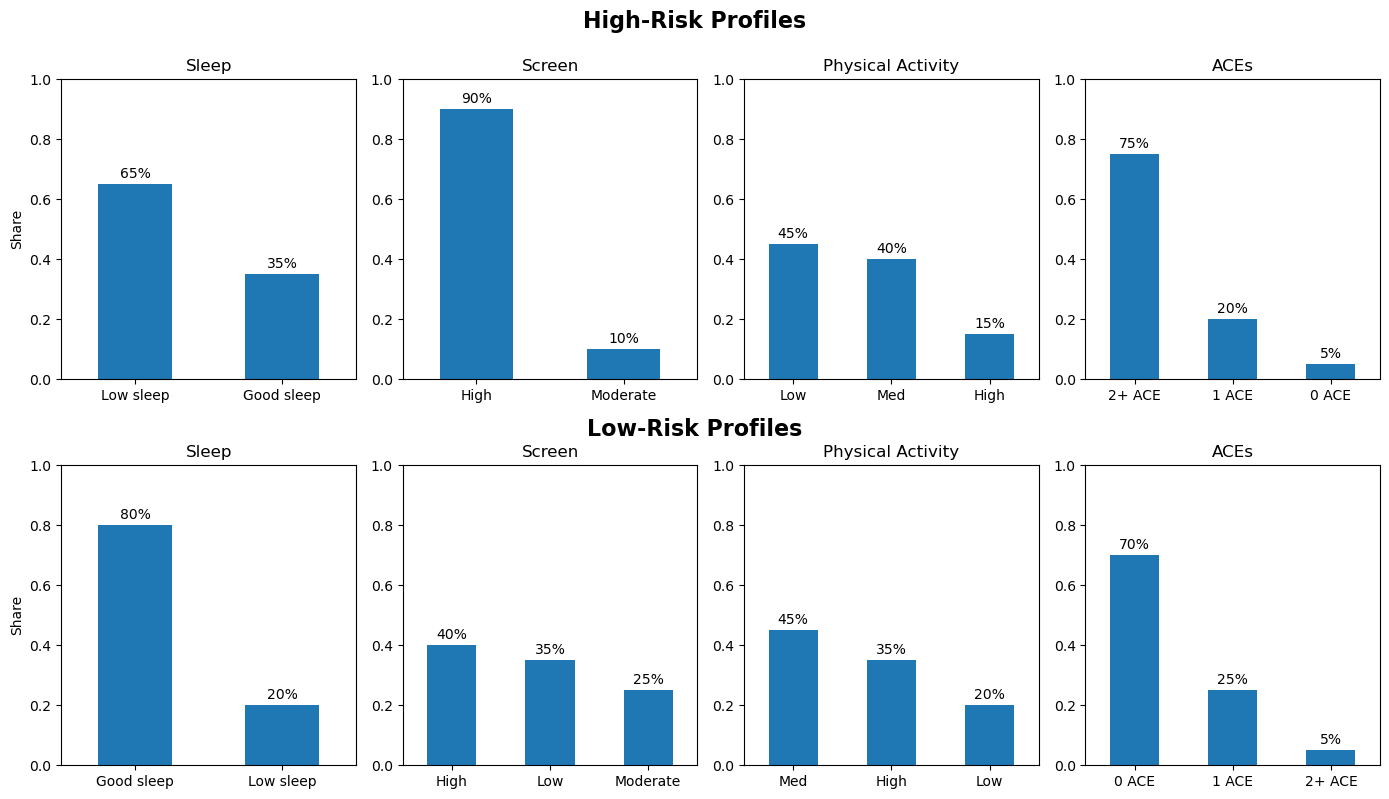

In [620]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

def plot_with_percent(ax, data, title):
    counts = data.map(label_map).value_counts(normalize=True)
    counts.plot(kind='bar', ax=ax)

    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Share')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylim(0, 1)

    for i, v in enumerate(counts):
        ax.text(i, v + 0.02, f"{v*100:.0f}%", ha='center')

# TOP ROW
plot_with_percent(axes[0, 0], top['sleep_group'], 'Sleep')
plot_with_percent(axes[0, 1], top['screen_group'], 'Screen')
plot_with_percent(axes[0, 2], top['activity_group'], 'Physical Activity')
plot_with_percent(axes[0, 3], top['ace_group'], 'ACEs')

# BOTTOM ROW
plot_with_percent(axes[1, 0], low['sleep_group'], 'Sleep')
plot_with_percent(axes[1, 1], low['screen_group'], 'Screen')
plot_with_percent(axes[1, 2], low['activity_group'], 'Physical Activity')
plot_with_percent(axes[1, 3], low['ace_group'], 'ACEs')

for ax in axes[:, 1:].flat:
    ax.set_ylabel('')

# Row titles
fig.text(0.5, 0.97, 'High-Risk Profiles', ha='center', fontsize=16, fontweight='bold')
fig.text(0.5, 0.46, 'Low-Risk Profiles', ha='center', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3.0)
plt.show()

#### Comparison of High- and Low-Risk Profiles

1. High-risk and low-risk profiles differ most clearly in screen exposure and adverse childhood experiences. High-risk profiles are dominated by high screen time and two or more ACEs, while low-risk profiles are characterized by no ACEs and a more balanced screen-time distribution.

2. Sleep does not show a strong or consistent difference between groups. Both high- and low-risk profiles include a mix of enough and not enough sleep, suggesting it is not a primary distinguishing factor.

3. Physical activity shows moderate differences. High-risk profiles are more associated with low activity, while low-risk profiles more often include medium or high activity levels.

##### Overall, the comparison suggests that psychosocial stress and screen-related behavior are the strongest distinguishing characteristics between low- and high-risk groups, while sleep plays a limited role and physical activity contributes moderately.

### From Exploration to Modeling

##### After identifying key factors associated with increased risk, the next step is to build a predictive model to estimate the probability of special health care needs based on these variables. The model learns patterns from the data and uses them to predict outcomes. Logistic regression is used as a baseline model because it is simple, interpretable, and effective for binary classification.

### The goal is to predict CSHCN_2324 status (0 = No, 1 = Yes)

1. Prepare data : convert target to 0/1

2. Select features.
Features were selected based on a combination of exploratory analysis and domain relevance, with a focus on interpretability and minimizing multicollinearity. Initial exploratory analysis was used to understand variables, while final feature inclusion was based on model performance and interpretability.

3. The model was trained using class balancing and `weight` as sample weights. Class balancing helps address the imbalance between CSHCN and non-CSHCN cases, while sample weights help preserve the population-representative structure of the NSCH survey.

In [621]:
df_model = df_clean.copy()

df_model['target'] = (df_model['target'] == 1).astype(int)

weights = df_model['weight']
weights = weights / weights.mean()

# Physical activity
# baseline = active_enough
df_model['low_activity'] = (df_model['physical_activity'] <= 2).astype(int)

# Screen time
# baseline = low_screen
df_model['moderate_screen'] = (df_model['screen_time'] == 3).astype(int)
df_model['high_screen'] = (df_model['screen_time'] >= 4).astype(int)

# Sleep
# baseline = sleep_enough
df_model['sleep_not_enough'] = (df_model['sleep'] == 2).astype(int)

# Flourishing
# baseline = flourishing_high
df_model['flourishing_low'] = (df_model['flourishing'] == 1).astype(int)
df_model['flourishing_moderate'] = (df_model['flourishing'] == 2).astype(int)

# ACEs
# baseline = ace_0
df_model['ace_1'] = (df_model['ace'] == 2).astype(int)
df_model['ace_2plus'] = (df_model['ace'] == 3).astype(int)

numerical_features = [
    'high_screen',
    'moderate_screen',
    'low_activity',
    'sleep_not_enough',
    'flourishing_low',
    'flourishing_moderate',
    'ace_1',
    'ace_2plus'
]

X = df_model[numerical_features]
y = df_model['target']

3. Train/test split.

    - Logistic regression was chosen as a baseline model due to its simplicity, interpretability, and effectiveness for binary classification problems.

In [622]:
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [623]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features)
    ]
)

4. Train model.

In [624]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

model.fit(X_train, y_train, model__sample_weight=weights_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


5. Evaluate.
    - Model performance was evaluated using classification metrics and ROC-AUC score. The ROC curve provides insight into the model’s ability to distinguish between classes across different thresholds.
    - In this problem, recall is more important than precision because failing to identify a high-risk child has more serious consequences than incorrectly flagging a low-risk child.

In [625]:
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob, sample_weight=weights_test)
print("ROC AUC:", auc)

for t in [0.5, 0.45, 0.4, 0.35]:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t,
        sample_weight=weights_test))

ROC AUC: 0.7433428709618815

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.71      0.78 10059.86789806463
           1       0.44      0.66      0.53 3477.8552048862193

    accuracy                           0.70 13537.723102950848
   macro avg       0.65      0.69      0.65 13537.723102950848
weighted avg       0.75      0.70      0.72 13537.723102950848


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.88      0.61      0.72 10059.86789806463
           1       0.41      0.76      0.53 3477.8552048862193

    accuracy                           0.65 13537.723102950848
   macro avg       0.64      0.69      0.63 13537.723102950848
weighted avg       0.76      0.65      0.67 13537.723102950848


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.88      0.61      0.72 10059.86789806463
           1       0.40      0.77      0.53 3477.8552048862193



1. ROC-AUC = 0.743, it is indicating solid predictive performance.

2. A threshold of 0.45 improves recall for high-risk children while maintaining acceptable overall performance, making it more suitable for identifying potential risk signals.

7. Feature importance.
    - The coefficients of the logistic regression model indicate the direction and strength of the relationship between each feature and the probability of having special health care needs.

In [626]:
coef = model.named_steps['model'].coef_[0]

feature_names = model.named_steps['preprocessing'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'odds_ratio': np.exp(coef)
}).sort_values(by='odds_ratio', ascending=False)

coef_df

,feature,coefficient,odds_ratio
4,num__flourishing_low,1.740962,5.702828
5,num__flourishing_moderate,0.952095,2.591133
7,num__ace_2plus,0.805188,2.237116
6,num__ace_1,0.284246,1.328760
2,num__low_activity,0.110165,1.116463
3,num__sleep_not_enough,0.059355,1.061152
0,num__high_screen,0.029624,1.030067
1,num__moderate_screen,-0.073828,0.928831


In [627]:
df_plot = coef_df.copy()

# Map names
feature_map = {
    'num__ace_2plus': '2+ ACEs',
    'num__ace_1': '1 ACE',

    'num__high_screen': 'High screen time',
    'num__moderate_screen': 'Moderate screen time',

    'num__sleep_not_enough': 'Not enough sleep',

    'num__low_activity': 'Low physical activity',

    'num__flourishing_low': 'Low flourishing',
    'num__flourishing_moderate': 'Moderate flourishing'
}

df_plot['feature_clean'] = df_plot['feature'].map(feature_map)

# Keep only mapped (important ones)
df_plot = df_plot.dropna(subset=['feature_clean'])

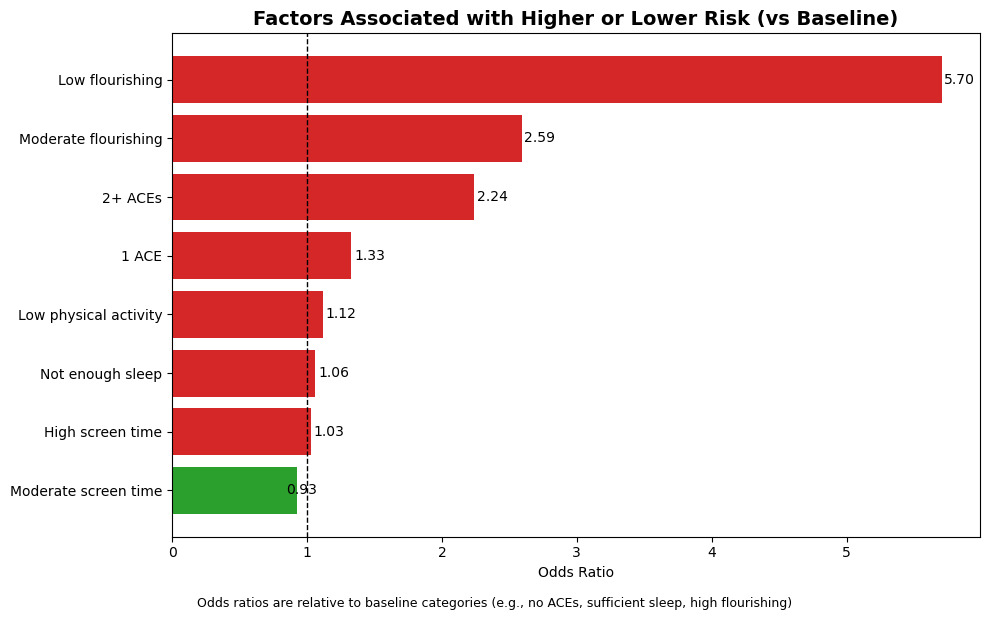

In [628]:
# Sort
df_plot = df_plot.sort_values('odds_ratio')

# Colors
colors = df_plot['odds_ratio'].apply(lambda x: '#2ca02c' if x < 1 else '#d62728')

plt.figure(figsize=(10, 6))

plt.barh(
    df_plot['feature_clean'],
    df_plot['odds_ratio'],
    color=colors
)

# Vertical line at 1
plt.axvline(1, color='black', linestyle='--', linewidth=1)

# Labels
for i, v in enumerate(df_plot['odds_ratio']):
    plt.text(v + 0.02 if v > 1 else v - 0.08, i, f"{v:.2f}", va='center')

plt.title('Factors Associated with Higher or Lower Risk (vs Baseline)', fontsize=14, fontweight='bold')
plt.xlabel('Odds Ratio')
plt.ylabel('')

plt.figtext(
    0.5, -0.02,
    'Odds ratios are relative to baseline categories (e.g., no ACEs, sufficient sleep, high flourishing)',
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.show()

1. Low flourishing shows the strongest association with increased risk

2. 2+ ACEs significantly increase the likelihood of CSHCN

3. Behavioral factors (low activity, high screen time, poor sleep) also contribute, but with smaller effects

4. Protective baseline conditions (e.g., no ACEs, high flourishing) are implicitly reflected through comparisons

### Conclusion (6–17 years old)

1. This analysis shows that certain psychosocial and behavioral patterns are strongly associated with a higher likelihood of special health care needs (CSHCN) in children. In particular, lower levels of emotional well-being (flourishing) and exposure to adverse childhood experiences (ACEs) are consistently linked with increased risk.

2. The results also highlight a cumulative effect: children exposed to multiple risk factors simultaneously are more likely to experience challenges than those with only one factor.

3. Overall, the findings suggest that child well-being is shaped by a combination of emotional, environmental, and behavioral factors, many of which are modifiable and can serve as early signals for additional support.

Recommendations (Parent-Focused)
1. Support emotional well-being

    - Emotional well-being (flourishing) appears strongly associated with lower risk. Creating a supportive and connected environment may help children build resilience.

    - Examples:
        - Spend regular one-on-one time
        - Encourage open communication
        - Support confidence and independence
    
2. Be aware of cumulative stress (ACEs)

    - Exposure to stress and adverse experiences is linked with higher risk, especially when multiple stressors are present.

    - Examples:
        - Maintain stable daily routines
        - Reduce exposure to stressful environments when possible
        - Seek support early if challenges arise

3. Monitor screen time habits

    - Higher screen exposure is associated with increased risk and may reflect broader lifestyle patterns.

    - Examples:
        - Set consistent daily limits
        - Encourage screen-free activities
        - Avoid screens before bedtime

4. Encourage regular physical activity

    - Physical activity is associated with healthier outcomes and can support both physical and emotional well-being.

    - Examples:
        - Aim for daily movement (play, walking, sports)
        - Focus on consistency rather than intensity

5. Focus on small, combined improvements

    - The findings suggest that combinations of factors matter more than any single behavior.

    - Example:
        - Improving sleep + reducing screen time + increasing activity → stronger combined effect than one change alone

### Next Steps

The next step is to turn this analysis into a parent-focused support concept. The goal is not to diagnose children, but to identify possible risk signals and provide practical, supportive recommendations.

Future steps include:

1. Build a simple parent-facing risk score based on the strongest signals from this analysis, especially flourishing, ACEs, and accumulated risk factors.

2. Create personalized recommendation categories, such as emotional well-being, cumulative stress, sleep routines, screen habits, and physical activity.

3. Test additional models and compare them with logistic regression using ROC-AUC, recall, and interpretability.

4. Improve the explanation layer so parents can understand why a child may be flagged as higher risk.

5. Design a prototype dashboard or app interface where parents answer simple questions and receive supportive, non-medical guidance.

This tool should be used for early awareness and support, not for clinical diagnosis.

### This analysis is based on survey data and identifies statistical patterns, not medical diagnoses. The goal is to highlight potential risk signals and areas that may benefit from further attention or discussion with professionals.